In [81]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [82]:
df = pd.read_csv(r"C:\Users\bipin\Downloads\Supply_chain_Data_Cleaned.csv")

In [83]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Region,Order State,Order Status,Product Card Id,Product Category Id,Product Name,Product Price,Shipping Date,Shipping Mode,Shipping Delay (days)
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Southeast Asia,Java Occidental,COMPLETE,1360,73,Smart watch,327.75,03-02-2018 22:56,Standard Class,-1
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,South Asia,Rajastán,PENDING,1360,73,Smart watch,327.75,18-01-2018 12:27,Standard Class,1
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,South Asia,Rajastán,CLOSED,1360,73,Smart watch,327.75,17-01-2018 12:06,Standard Class,0
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Oceania,Queensland,COMPLETE,1360,73,Smart watch,327.75,16-01-2018 11:45,Standard Class,-1
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Oceania,Queensland,PENDING_PAYMENT,1360,73,Smart watch,327.75,15-01-2018 11:24,Standard Class,-2


In [84]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Fname', 'Customer Id', 'Customer Lname',
       'Customer Segment', 'Customer State', 'Customer Street',
       'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude',
       'Longitude', 'Market', 'Order City', 'Order Country',
       'Order Customer Id', 'Order Date', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Product Card Id', 'Product Category Id', 'Product Name',
       'Product Price', 'Shipping Date', 'Shipping Mode',
       'Shipping Del

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 48 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Fname                 180519 non-null  object 
 12  Customer Id                   

In [86]:
df.isnull().sum()

Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Id                      0
Category Name                    0
Customer City                    0
Customer Country                 0
Customer Fname                   0
Customer Id                      0
Customer Lname                   8
Customer Segment                 0
Customer State                   0
Customer Street                  0
Customer Zipcode                 3
Department Id                    0
Department Name                  0
Latitude                         0
Longitude                        0
Market                           0
Order City                       0
Order Country                    0
Order Customer Id                0
Order Date                       0
Order Id                         0
Order Item Cardprod 

In [87]:
df.duplicated().sum()

np.int64(0)

In [88]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.497654,1.623722,0.000000,2.000000,3.000000,5.000000,6.000000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.000000,2.000000,4.000000,4.000000,4.000000
Benefit per order,180519.0,21.974989,104.433526,-4274.979980,7.000000,31.520000,64.800003,911.799988
Sales per customer,180519.0,183.107609,120.043670,7.490000,104.379997,163.990005,247.399994,1939.989990
Late_delivery_risk,180519.0,0.548291,0.497664,0.000000,0.000000,1.000000,1.000000,1.000000
Category Id,180519.0,31.851451,15.640064,2.000000,18.000000,29.000000,45.000000,76.000000
Customer Id,180519.0,6691.379495,4162.918106,1.000000,3258.500000,6457.000000,9779.000000,20757.000000
Customer Zipcode,180516.0,35921.126914,37542.461122,603.000000,725.000000,19380.000000,78207.000000,99205.000000
Department Id,180519.0,5.443460,1.629246,2.000000,4.000000,5.000000,7.000000,12.000000
Latitude,180519.0,29.719955,9.813646,-33.937553,18.265432,33.144863,39.279617,48.781933


In [89]:
numeric_cols = [i for i in df.columns if df[i].dtype in ['int64', 'float64']]
numeric_cols

['Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Late_delivery_risk',
 'Category Id',
 'Customer Id',
 'Customer Zipcode',
 'Department Id',
 'Latitude',
 'Longitude',
 'Order Customer Id',
 'Order Id',
 'Order Item Cardprod Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Product Card Id',
 'Product Category Id',
 'Product Price',
 'Shipping Delay (days)']

In [90]:
categorical_cols = [i for i in df.columns if df[i].dtype == 'object']

In [91]:
categorical_cols

['Type',
 'Delivery Status',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Fname',
 'Customer Lname',
 'Customer Segment',
 'Customer State',
 'Customer Street',
 'Department Name',
 'Market',
 'Order City',
 'Order Country',
 'Order Date',
 'Order Region',
 'Order State',
 'Order Status',
 'Product Name',
 'Shipping Date',
 'Shipping Mode']

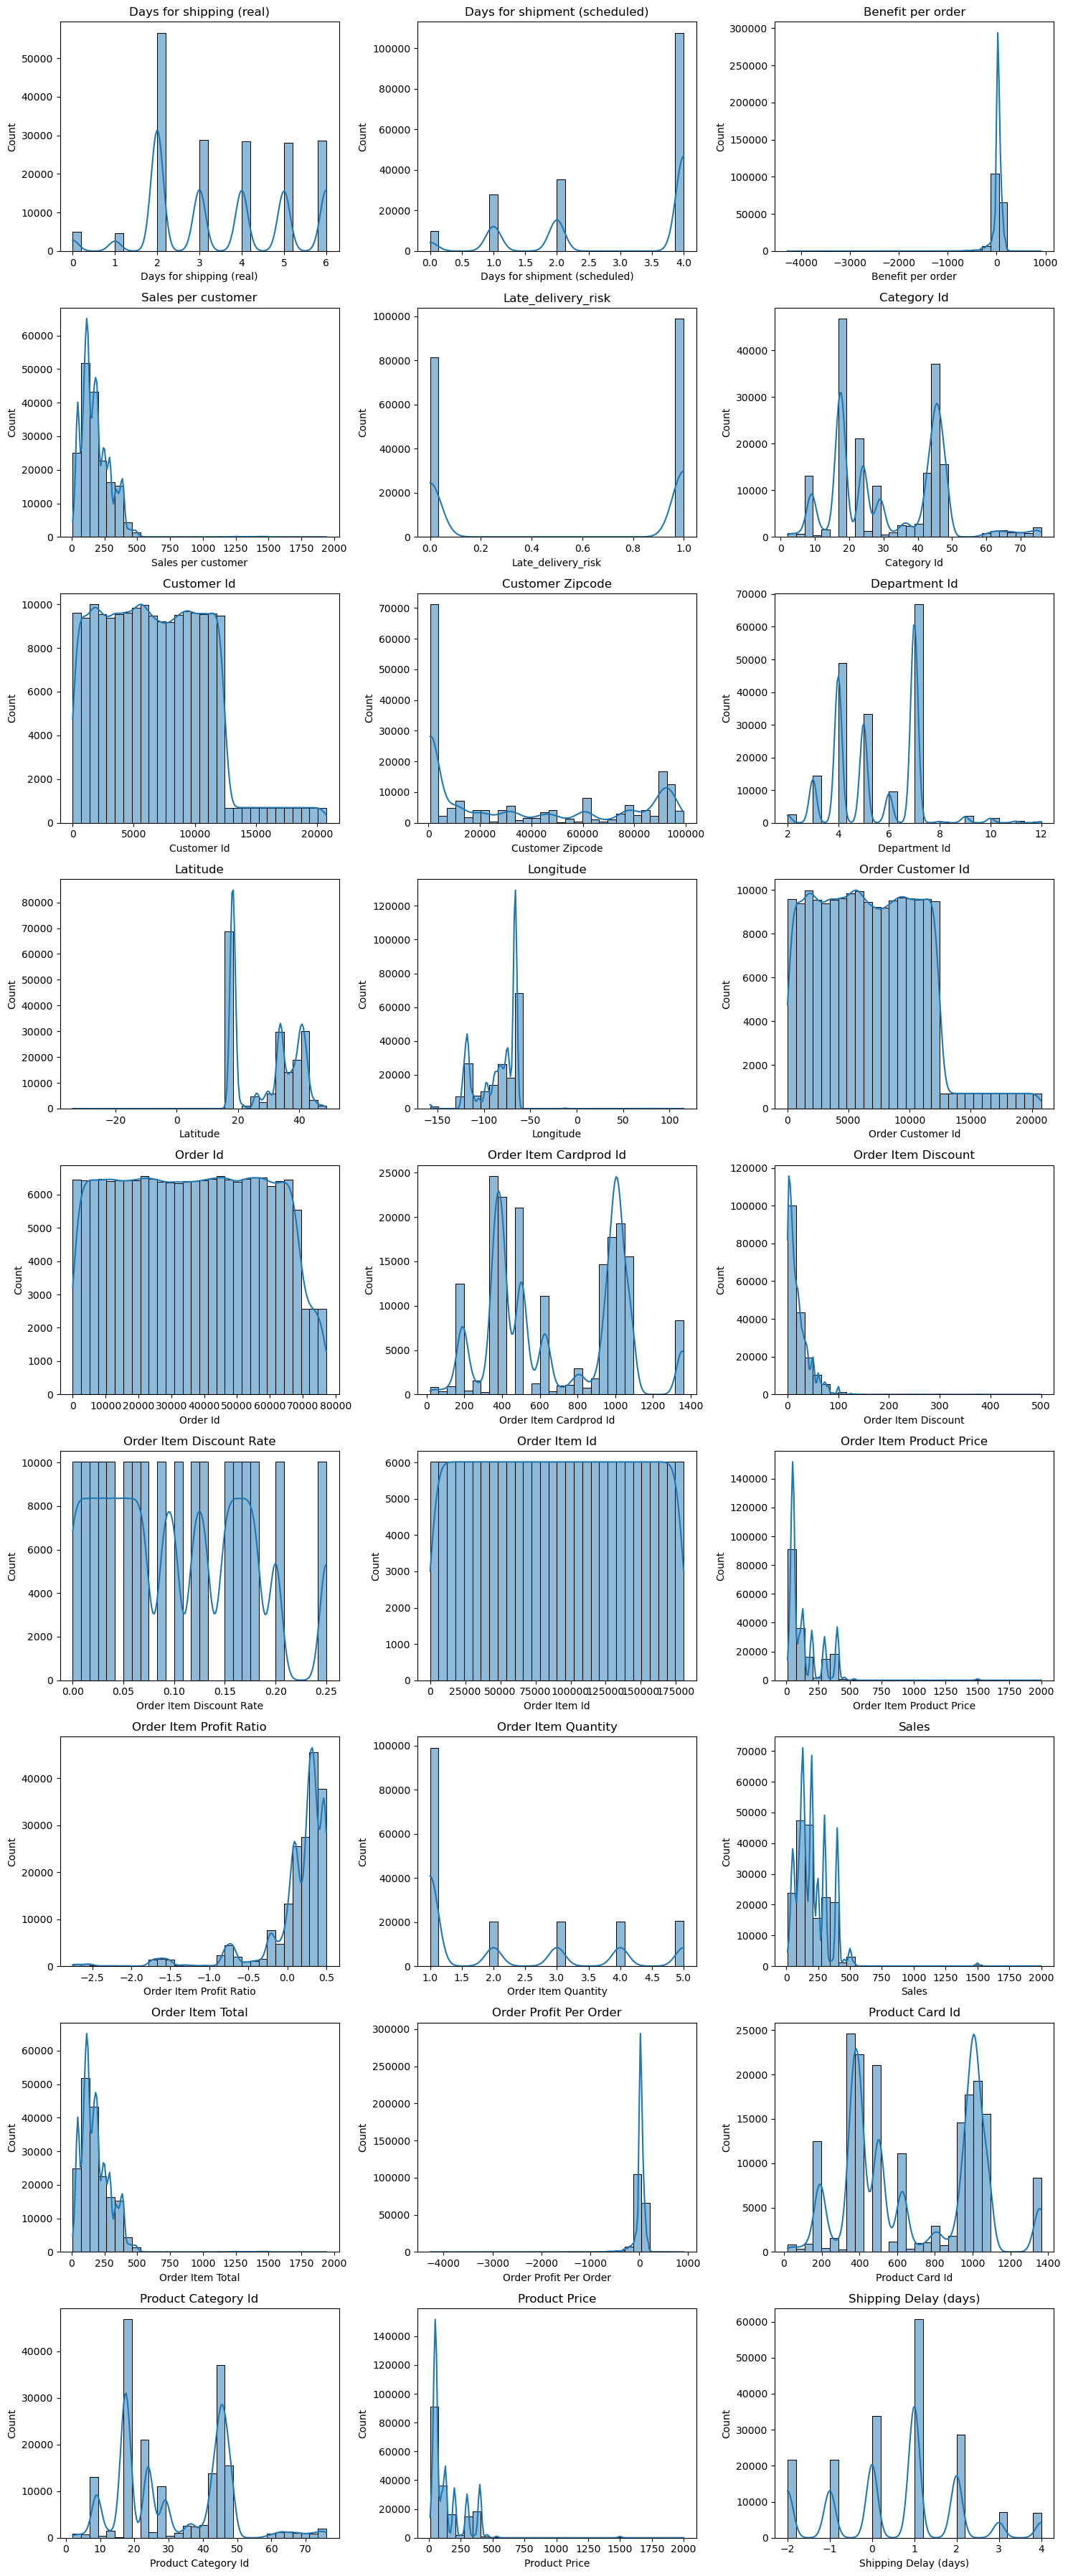

In [92]:
import math

cols = 3
rows = math.ceil(len(numeric_cols) / cols)

plt.figure(figsize=(15, rows * 4))

for i, col in enumerate(numeric_cols):
    plt.subplot(rows, cols, i + 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

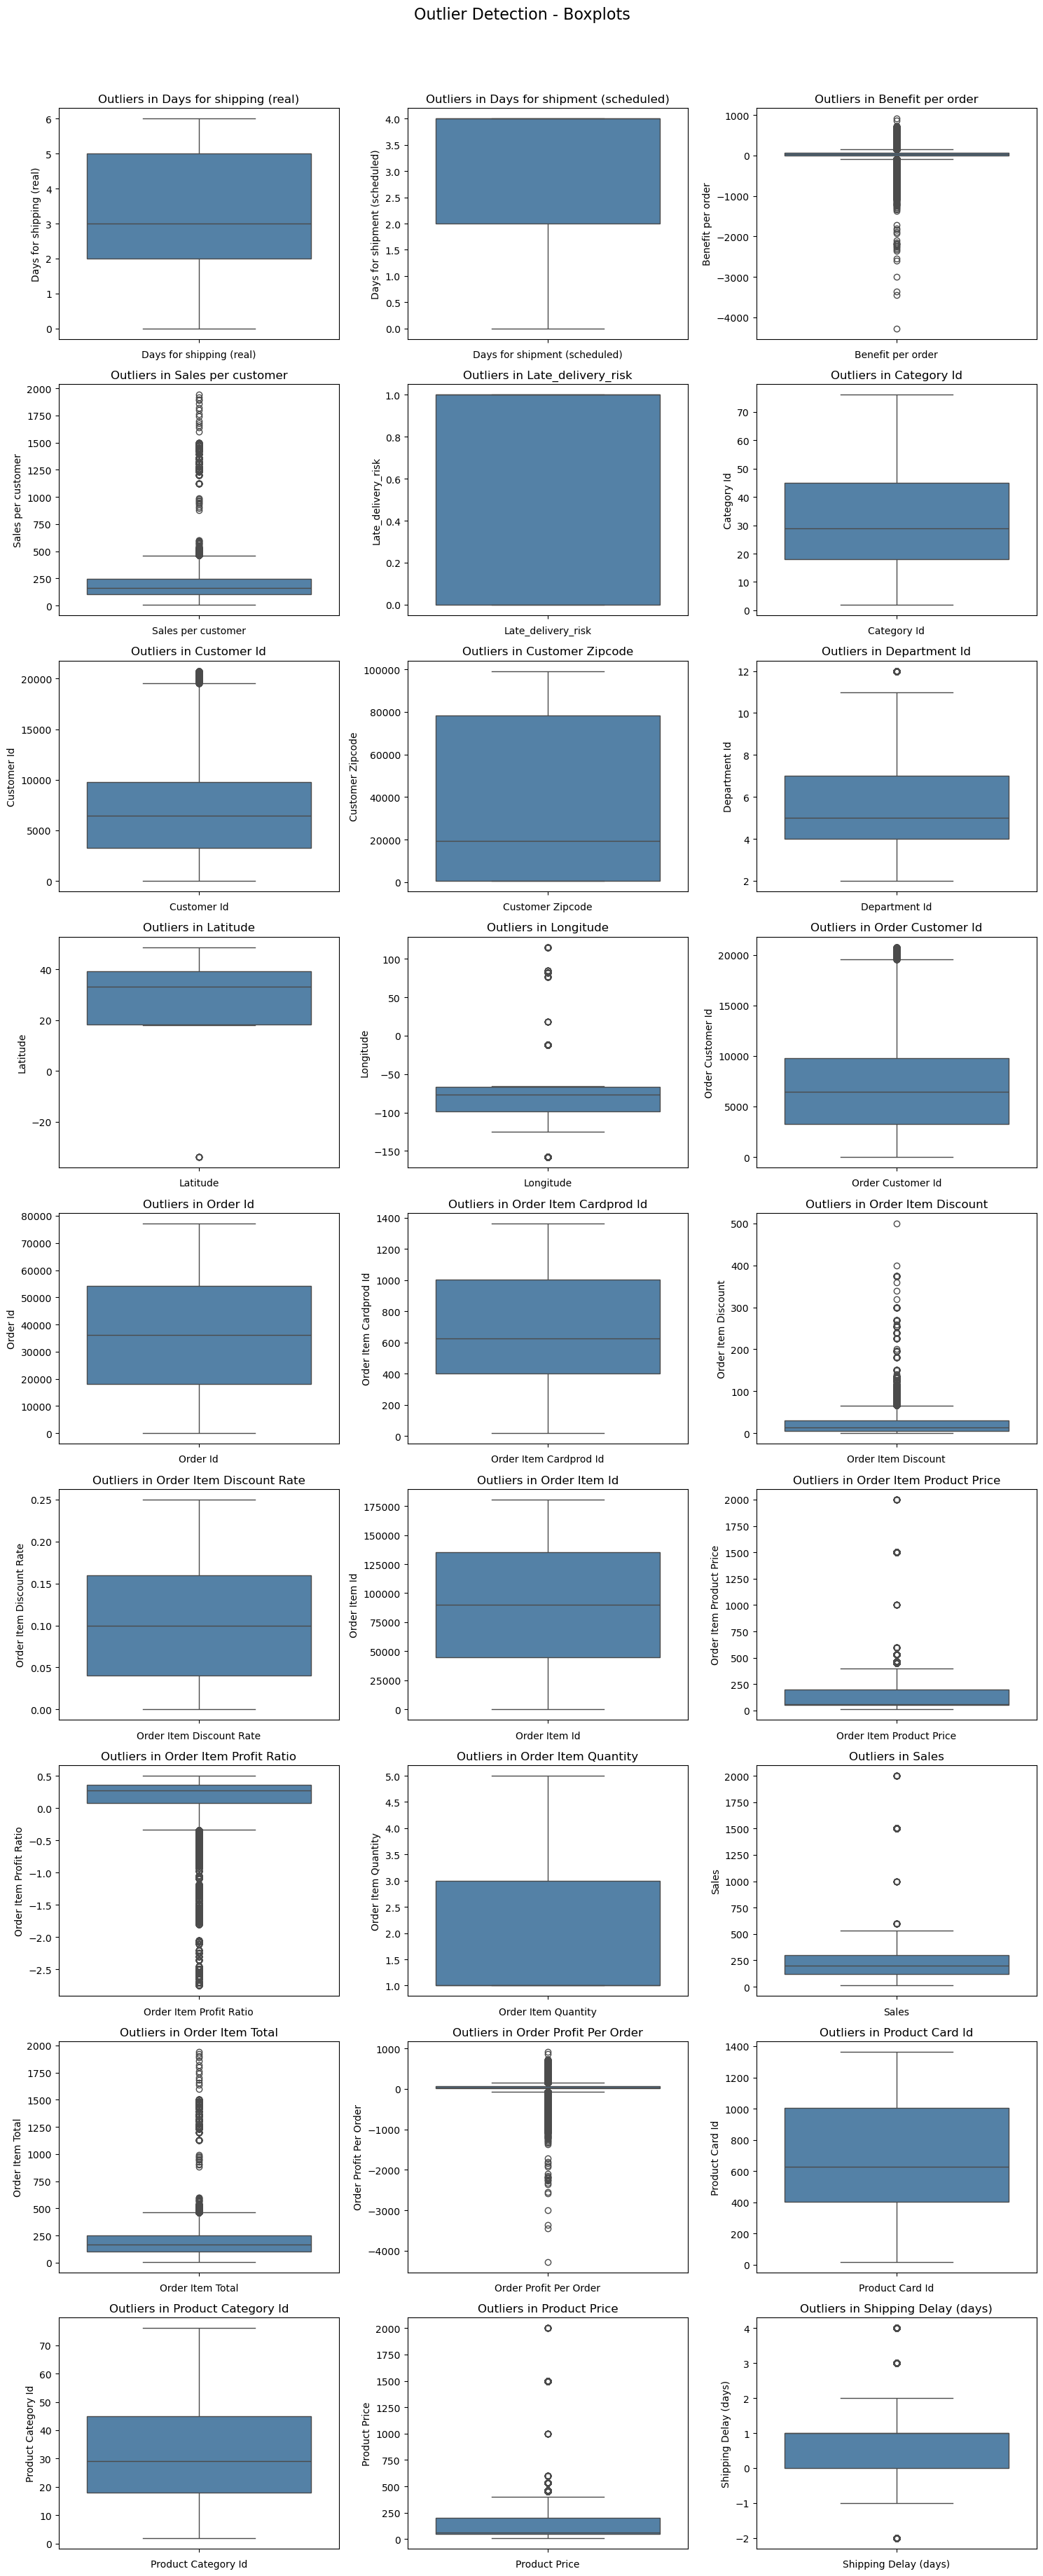

In [93]:
# For Checking the Outlier in numerical col.
plt.figure(figsize=(15, rows * 4))

for i, col in enumerate(numeric_cols):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(df[col], color='steelblue')
    plt.title(f'Outliers in {col}')
    plt.xlabel(col)

plt.suptitle('Outlier Detection - Boxplots', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()



In [94]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"{col}: {len(outliers)} outliers")

Days for shipping (real): 0 outliers
Days for shipment (scheduled): 0 outliers
Benefit per order: 18942 outliers
Sales per customer: 1943 outliers
Late_delivery_risk: 0 outliers
Category Id: 0 outliers
Customer Id: 1198 outliers
Customer Zipcode: 0 outliers
Department Id: 362 outliers
Latitude: 9 outliers
Longitude: 1414 outliers
Order Customer Id: 1198 outliers
Order Id: 0 outliers
Order Item Cardprod Id: 0 outliers
Order Item Discount: 7537 outliers
Order Item Discount Rate: 0 outliers
Order Item Id: 0 outliers
Order Item Product Price: 2048 outliers
Order Item Profit Ratio: 17300 outliers
Order Item Quantity: 0 outliers
Sales: 488 outliers
Order Item Total: 1943 outliers
Order Profit Per Order: 18942 outliers
Product Card Id: 0 outliers
Product Category Id: 0 outliers
Product Price: 2048 outliers
Shipping Delay (days): 35701 outliers


# Data Cleaning 

In [95]:
df["order_date"] = pd.to_datetime(df["Order Date"], format="%d-%m-%Y %H:%M")
df["shipping_date"] = pd.to_datetime(df["Shipping Date"], format="%d-%m-%Y %H:%M")

In [96]:
df["order_year"]  = df["order_date"].dt.year
df["order_month"] = df["order_date"].dt.month
df["order_day"]   = df["order_date"].dt.day
df["order_month_name"] = df["order_date"].dt.month_name()
df["order_day_name"]   = df["order_date"].dt.day_name()
df["order_quarter"] = df["order_date"].dt.quarter
df["shipping_quarter"] =  df["shipping_date"].dt.quarter

In [97]:
print(df[["order_date", "order_year", "order_month", "order_day",
          "order_month_name", "order_day_name", "order_quarter"]].head())

           order_date  order_year  order_month  order_day order_month_name  \
0 2018-01-31 22:56:00        2018            1         31          January   
1 2018-01-13 12:27:00        2018            1         13          January   
2 2018-01-13 12:06:00        2018            1         13          January   
3 2018-01-13 11:45:00        2018            1         13          January   
4 2018-01-13 11:24:00        2018            1         13          January   

  order_day_name  order_quarter  
0      Wednesday              1  
1       Saturday              1  
2       Saturday              1  
3       Saturday              1  
4       Saturday              1  


In [98]:
df["profit"]=df["Sales"]-df["Order Item Product Price"]


In [99]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,order_date,shipping_date,order_year,order_month,order_day,order_month_name,order_day_name,order_quarter,shipping_quarter,profit
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,2018-01-31 22:56:00,2018-02-03 22:56:00,2018,1,31,January,Wednesday,1,1,0.0
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,2018-01-13 12:27:00,2018-01-18 12:27:00,2018,1,13,January,Saturday,1,1,0.0
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,2018-01-13 12:06:00,2018-01-17 12:06:00,2018,1,13,January,Saturday,1,1,0.0
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,2018-01-13 11:45:00,2018-01-16 11:45:00,2018,1,13,January,Saturday,1,1,0.0
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,2018-01-13 11:24:00,2018-01-15 11:24:00,2018,1,13,January,Saturday,1,1,0.0


## KPI's

In [100]:
#  On-Time Delivery Rate
on_time = df['Delivery Status'].isin(['Shipping on time', 'Advance shipping'])
On_Time_Delivery_Rate = round(on_time.mean() * 100, 2)
print(f"On Time Delivery Rate:{On_Time_Delivery_Rate} %") 

On Time Delivery Rate:40.88 %


In [101]:
# Late Delivery Rate
Late_Delivery_Rate= round((df['Delivery Status'] == 'Late delivery').mean() * 100, 2)
print(f" Late Delivery Rate:{Late_Delivery_Rate} %") 

 Late Delivery Rate:54.83 %


In [102]:
# Average Shipping Delay
avg_shipping_delay = round(df['Shipping Delay (days)'].mean(), 2)
print(f"Average Shipping Delay: {avg_shipping_delay} days")
 

Average Shipping Delay: 0.57 days


In [103]:
# Scheduled vs Real Shipping Gap
gap = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']
Avg_Schedule_Gap = round(gap.mean(), 2)
print(f"Avg_Schedule_Gap: {Avg_Schedule_Gap }Days")

Avg_Schedule_Gap: 0.57Days


In [104]:
# Total Revenue
Total_Revenue = round(df['Sales'].sum()/1000000, 2) 
print(f"Total_Revenue_($) :${Total_Revenue} M")

Total_Revenue_($) :$36.78 M


In [105]:
# Total Profit
Total_Profit = round(df['Order Profit Per Order'].sum()/1000000, 2)
print(f"Total_Profit_($) :${Total_Profit} M")

Total_Profit_($) :$3.97 M


In [106]:
#  Overall Profit Margin 
Profit_Margin = round(df['Order Profit Per Order'].sum() / df['Sales'].sum() * 100,2)
print(f" Overall Profit Margin %: {Profit_Margin} %")

 Overall Profit Margin %: 10.78 %


In [107]:
# Orders at a Loss
Orders_at_Loss = round((df['Order Profit Per Order'] < 0).mean() * 100, 2)
print(f"Orders at a Loss %: {Orders_at_Loss} %")

Orders at a Loss %: 18.71 %


In [108]:
# Average Order Value
Avg_Order_Value = round(df.groupby('Order Id')['Sales'].sum().mean(), 2)
print(f"Average Order Value: ${Avg_Order_Value}")

Average Order Value: $559.45


In [109]:
# Order Fulfillment Rate
completed = df['Order Status'].isin(['COMPLETE', 'CLOSED'])
Order_Fulfillment_Rate = round(completed.mean() * 100, 2)
print(f"Order Fulfillment Rate: {Order_Fulfillment_Rate} %")

Order Fulfillment Rate: 43.82 %


In [110]:
# Avg Items per Order 
Avg_Items_per_Order = round(df.groupby('Order Id')['Order Item Quantity'].sum().mean(), 2)
print(f"Avg Items per Order: {Avg_Items_per_Order}")

Avg Items per Order: 5.84


In [111]:
# Late Delivery Risk Rate
Late_Delivery_Risk_Rate = round(df['Late_delivery_risk'].mean() * 100, 2)
print(f"Late Delivery Risk Rate:{Late_Delivery_Risk_Rate} %")

Late Delivery Risk Rate:54.83 %


In [112]:
#  Avg Discount Rate
Avg_Discount_Rate = round(df['Order Item Discount Rate'].mean() * 100, 2)
print(f" Avg Discount Rate: {Avg_Discount_Rate} %")
 


 Avg Discount Rate: 10.17 %


In [113]:
# Avg Profit Ratio per Item
Avg_Profit_Ratio_per_Item = round(df['Order Item Profit Ratio'].mean() * 100, 2)
print(f"Avg Profit Ratio per Item: {Avg_Profit_Ratio_per_Item } %")

Avg Profit Ratio per Item: 12.06 %


#  Business Insights

###   DELIVERY & SHIPPING ANALYSIS

In [114]:
delivery_counts = df['Delivery Status'].value_counts()
print(f"\n  Delivery Status Distribution:")
print(delivery_counts.to_string())



  Delivery Status Distribution:
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754


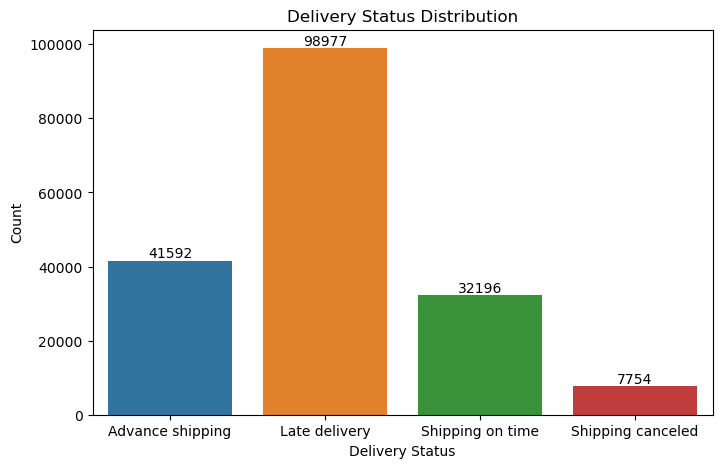

In [115]:
plt.figure(figsize=(8,5))
ax = sns.countplot(x='Delivery Status', data=df,hue="Delivery Status")

# Add data labels
for container in ax.containers:
    ax.bar_label(container)

# Titles and labels
plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Count")

plt.show()


In [116]:
late_pct = (df['Delivery Status'] == 'Late delivery').mean() * 100
print(f"\n  Late Delivery Rate : {late_pct:.1f}%")


  Late Delivery Rate : 54.8%


In [117]:
# Shipping delay stats
delay = df['Shipping Delay (days)']
print(f"\n  Shipping Delay Stats (days):")
print(f"   Mean   : {delay.mean():.2f}")
print(f"   Median : {delay.median():.2f}")
print(f"   Max    : {delay.max():.2f}")
print(f"   % with delay > 0 : {(delay > 0).mean()*100:.1f}%")



  Shipping Delay Stats (days):
   Mean   : 0.57
   Median : 1.00
   Max    : 4.00
   % with delay > 0 : 57.3%


In [118]:
# Late delivery risk
risk_pct = df['Late_delivery_risk'].mean() * 100
print(f"\n  Late Delivery Risk (1=High): {risk_pct:.1f}% of orders flagged")
 


  Late Delivery Risk (1=High): 54.8% of orders flagged


In [119]:
# Shipping mode performance
Shipping_mode_performance=df.groupby('Shipping Mode')['Shipping Delay (days)'].mean().round(2).sort_values(ascending=False)
Shipping_mode_performance

Shipping Mode
Second Class      1.99
First Class       1.00
Same Day          0.48
Standard Class   -0.00
Name: Shipping Delay (days), dtype: float64

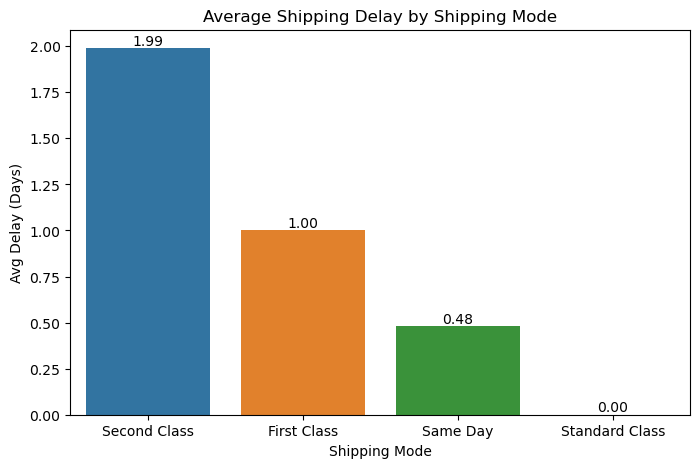

In [120]:
shipping_df = Shipping_mode_performance.reset_index()
plt.figure(figsize=(8,5))
ax = sns.barplot(
    x='Shipping Mode',
    y='Shipping Delay (days)',
    data=shipping_df,hue="Shipping Mode"
)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

# Titles and labels
plt.title("Average Shipping Delay by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Avg Delay (Days)")

plt.show()

###  SALES & PROFIT ANALYSIS

In [121]:
# Sales 
if 'Sales' in df.columns:
    print(f"  Total Sales      : ${df['Sales'].sum():,.2f}")
    print(f"  Avg Sales/Order  : ${df['Sales'].mean():,.2f}")

  Total Sales      : $36,784,735.01
  Avg Sales/Order  : $203.77


In [122]:
# Profit  
if 'Order Profit Per Order' in df.columns:
    print(f"  Total Profit     : ${df['Order Profit Per Order'].sum():,.2f}")
    print(f"  Avg Profit/Order : ${df['Order Profit Per Order'].mean():,.2f}")
    neg_pct = (df['Order Profit Per Order'] < 0).mean() * 100
    print(f"  Orders at Loss   : {neg_pct:.1f}%")


  Total Profit     : $3,966,902.97
  Avg Profit/Order : $21.97
  Orders at Loss   : 18.7%


In [123]:
# Top 5 Profitable Categories
print(f"\n  Top 5 Profitable Categories:")
top_cat = df.groupby('Category Name')['Order Profit Per Order'].sum().sort_values(ascending=False).head(5)
print(top_cat.round(2).to_string())


  Top 5 Profitable Categories:
Category Name
Fishing             756220.77
Cleats              494636.92
Camping & Hiking    427455.57
Cardio Equipment    383011.10
Women's Apparel     350421.03


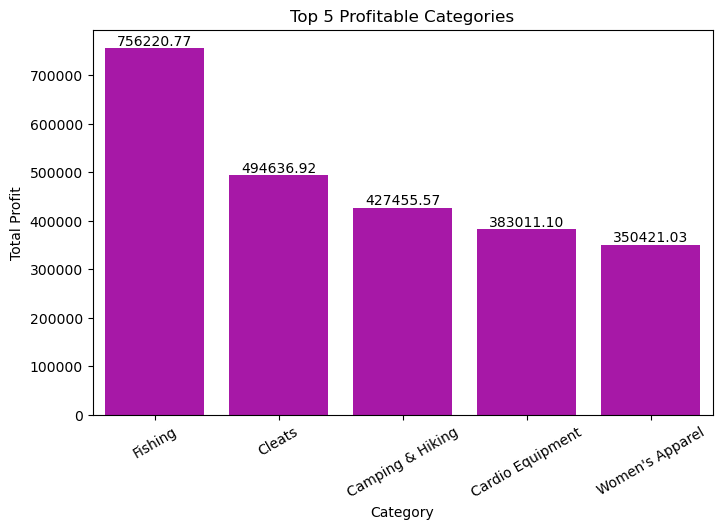

In [124]:
top_cat_df = top_cat.reset_index()

# Plot
plt.figure(figsize=(8,5))
ax = sns.barplot(
    x='Category Name',
    y='Order Profit Per Order',
    data=top_cat_df,color="m"
)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
    
plt.title("Top 5 Profitable Categories")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=30)

plt.show()

In [125]:
# Sales by Customer Segment
top_customers_Segment = df.groupby('Customer Segment')['Sales'].sum().sort_values(ascending=False).round(2)
print(f"\n  Sales by Customer Segment:")
print(top_customers_Segment)


  Sales by Customer Segment:
Customer Segment
Consumer       19095790.16
Corporate      11168406.84
Home Office     6520538.02
Name: Sales, dtype: float64


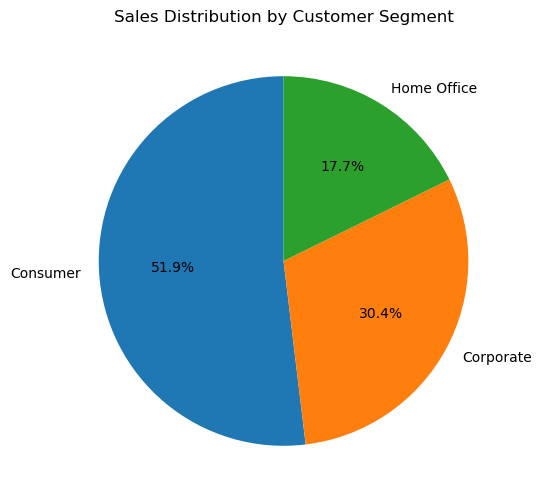

In [126]:
# Plot pie chart
plt.figure(figsize=(6,6))

plt.pie(
    top_customers_Segment,
    labels=top_customers_Segment.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Sales Distribution by Customer Segment")

plt.show()

### GEOGRAPHIC ANALYSIS

In [127]:
# Orders by Market
order_market=df['Market'].value_counts().sort_values(ascending=False)
print(order_market)

Market
LATAM           51594
Europe          50252
Pacific Asia    41260
USCA            25799
Africa          11614
Name: count, dtype: int64


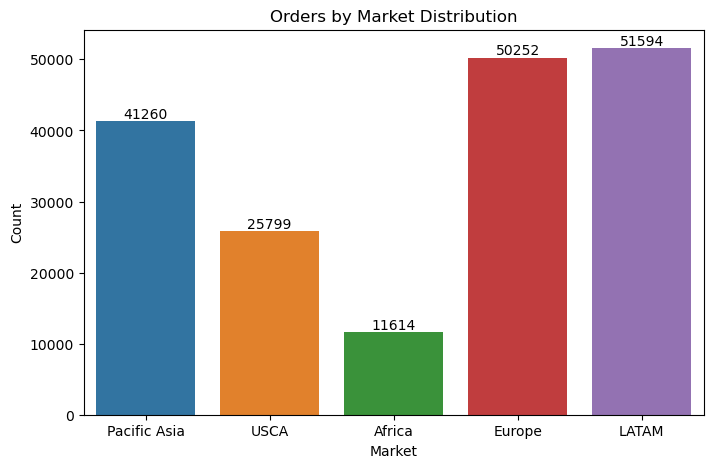

In [128]:
plt.figure(figsize=(8,5))
ax = sns.countplot(x='Market', data=df,hue="Market")

# Add data labels
for container in ax.containers:
    ax.bar_label(container)

# Titles and labels
plt.title("Orders by Market Distribution")
plt.xlabel("Market")
plt.ylabel("Count")

plt.show()

In [129]:
# Top 5 Regions by Sales
Region_sales = (
    df.groupby('Order Region')['Sales']
    .sum()
    .sort_values(ascending=False)
    
    .div(1_000_000)
    .round(2)
)

print("\nTop 5 Region Sales (in Millions):")
print(Region_sales.astype(str) + "M")


Top 5 Region Sales (in Millions):
Order Region
Western Europe     5.89M
Central America    5.67M
South America      2.96M
Northern Europe    2.16M
Southern Europe    2.05M
Oceania            2.02M
Southeast Asia     1.93M
Caribbean          1.65M
West of USA        1.57M
South Asia         1.55M
Eastern Asia       1.49M
East of USA        1.37M
West Asia          1.17M
US Center          1.15M
South of  USA      0.79M
Eastern Europe     0.77M
West Africa        0.73M
North Africa       0.63M
East Africa        0.38M
Central Africa     0.33M
Southern Africa    0.23M
Canada             0.19M
Central Asia       0.11M
Name: Sales, dtype: object


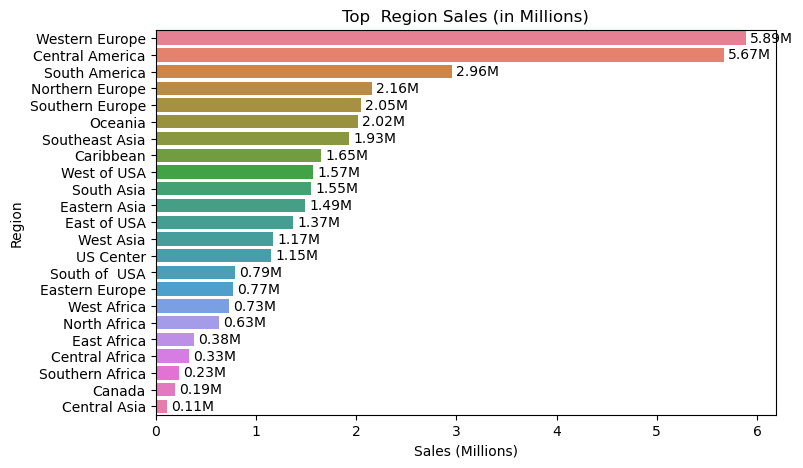

In [130]:
region_df = Region_sales.reset_index()
plt.figure(figsize=(8,5))
ax = sns.barplot(
    y='Order Region',
    x='Sales',
    data=region_df,hue="Order Region"
)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2fM', padding=3)

# Titles and labels
plt.title("Top  Region Sales (in Millions)")
plt.xlabel("Sales (Millions)")
plt.ylabel("Region")

plt.show()

###  PRODUCT ANALYSIS

In [131]:
# Top 10 Products by Quantity Sold
top_prod = df.groupby('Product Name')['Order Item Quantity'].sum().sort_values(ascending=False).head(10)
print(top_prod.to_string())

Product Name
Perfect Fitness Perfect Rip Deck                 73698
Nike Men's Dri-FIT Victory Golf Polo             62956
O'Brien Men's Neoprene Life Vest                 57803
Nike Men's Free 5.0+ Running Shoe                36680
Under Armour Girls' Toddler Spine Surge Runni    31735
Nike Men's CJ Elite 2 TD Football Cleat          22246
Field & Stream Sportsman 16 Gun Fire Safe        17325
Pelican Sunstream 100 Kayak                      15500
Diamondback Women's Serene Classic Comfort Bi    13729
ENO Atlas Hammock Straps                           998


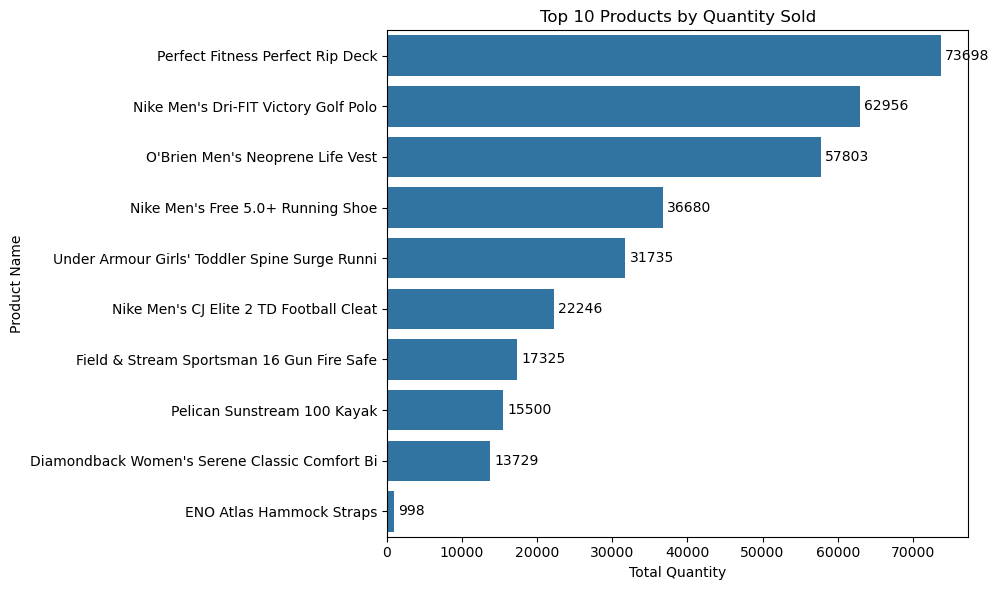

In [132]:
top_prod = top_prod.reset_index()
top_prod.columns = ['Product Name', 'Order Item Quantity']  

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top_prod, 
                 x='Order Item Quantity', 
                 y='Product Name')

# Add data labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Total Quantity")
plt.ylabel("Product Name")
plt.tight_layout()
plt.show()

In [133]:
# Sales by Department
dept_sales=df.groupby('Department Name')['Sales'].sum().sort_values(ascending=False).round(2)
print(dept_sales)

Department Name
Fan Shop             17113870.94
Apparel               7976255.34
Golf                  4609028.24
Footwear              4006498.77
Outdoors              1253351.45
Technology            1039598.97
Fitness                397050.89
Discs Shop             228887.73
Health and Beauty      106080.48
Pet Shop                41524.80
Book Shop               12587.40
Name: Sales, dtype: float64


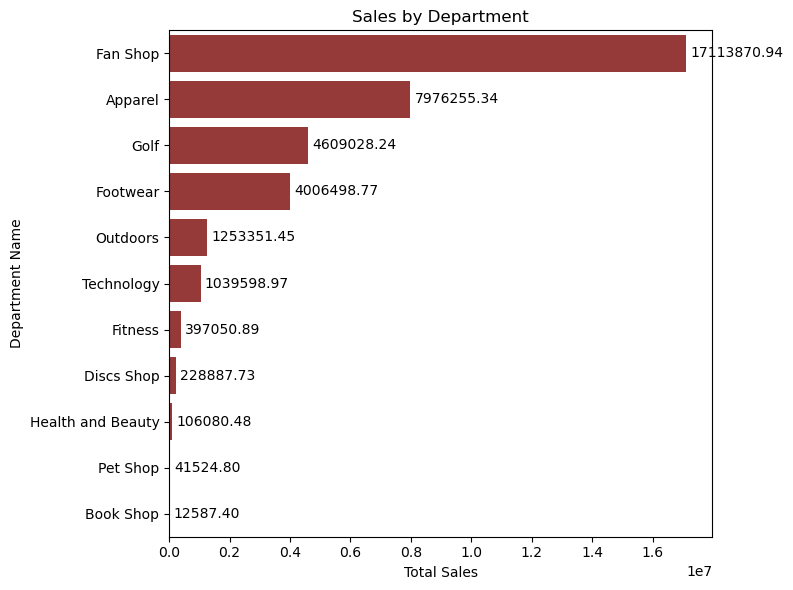

In [134]:


# Convert Series → DataFrame
dept_sales_df = dept_sales.reset_index()

# Plot
plt.figure(figsize=(8,6))
ax = sns.barplot(data=dept_sales_df,
                 x='Sales',
                 y='Department Name',color="brown")

# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.title("Sales by Department")
plt.xlabel("Total Sales")
plt.ylabel("Department Name")
plt.tight_layout()
plt.show()

### : Delivery Status

In [135]:
counts = df['Delivery Status'].value_counts()
print(counts)

Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64


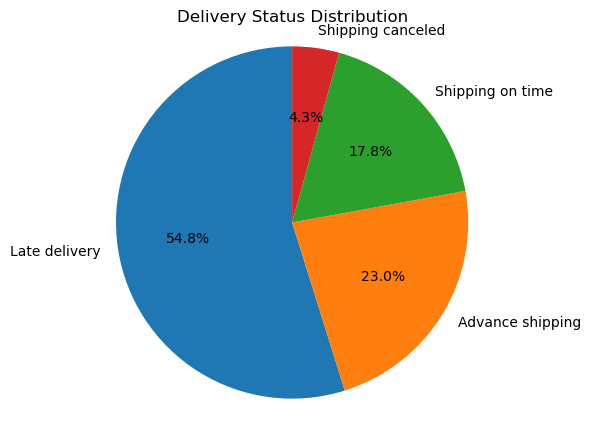

In [136]:
plt.figure(figsize=(5,5))
plt.pie(counts, 
        labels=counts.index, 
        autopct='%1.1f%%', 
        startangle=90)

plt.title("Delivery Status Distribution")
plt.axis('equal')  # Makes circle perfect
plt.show()

### Monthly, weekday, Quarterly, and yearly trend

In [137]:
#  yearly Trend
yearly_sales = (df.groupby("order_year")["Sales"]
                .sum() / 1_000_000).round(2)

yearly_sales = yearly_sales.astype(str) + "M"

print(yearly_sales)

order_year
2015    12.34M
2016     12.3M
2017    11.81M
2018     0.33M
Name: Sales, dtype: object


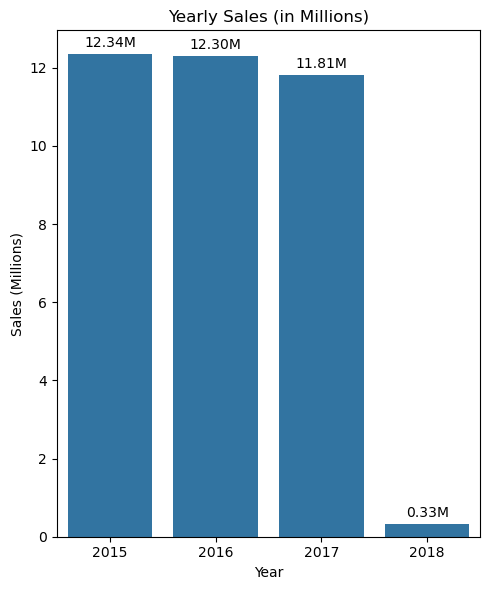

In [138]:
yearly_sales = (df.groupby("order_year")["Sales"]
                .sum() / 1_000_000).round(2).reset_index()
yearly_sales.columns = ['order_year', 'Sales']

plt.figure(figsize=(5, 6))
ax = sns.barplot(data=yearly_sales,
                 x='order_year',
                 y='Sales')
for container in ax.containers:
    ax.bar_label(container,
                 labels=[f"{v.get_height():.2f}M" for v in container],
                 padding=3)

plt.title("Yearly Sales (in Millions)")
plt.xlabel("Year")
plt.ylabel("Sales (Millions)")
plt.tight_layout()
plt.show()

In [139]:
# Late delivery Status year  Wise
delivery_pivot = df.pivot_table(index='Delivery Status',
                               columns='order_year',
                               aggfunc='size',
                               fill_value=0)

print(delivery_pivot)

order_year          2015   2016   2017  2018
Delivery Status                             
Advance shipping   14597  14199  12328   468
Late delivery      34372  34446  28964  1195
Shipping canceled   2696   2624   2348    86
Shipping on time   10985  11281   9556   374


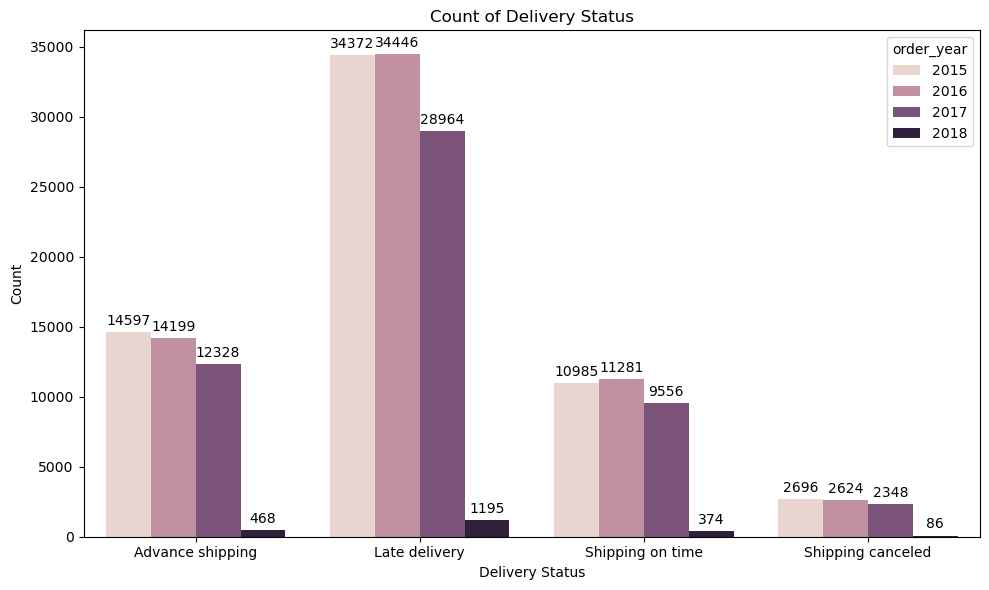

In [140]:
plt.figure(figsize=(10,6))

ax = sns.countplot(data=df, x='Delivery Status',hue="order_year")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title("Count of Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [141]:
# Weekely Trand
monthly_sales = (df.groupby("order_month_name")
                 .agg({"Sales": "sum", "profit": "sum"}) / 1_000_000).round(2)

print(monthly_sales)

                  Sales  profit
order_month_name               
April              3.05    1.00
August             3.19    1.05
December           2.60    0.71
February           2.89    0.97
January            3.46    1.05
July               3.19    1.05
June               3.06    0.98
March              3.13    1.04
May                3.19    1.05
November           2.70    0.68
October            3.17    0.72
September          3.16    0.99


<Figure size 1500x1000 with 0 Axes>

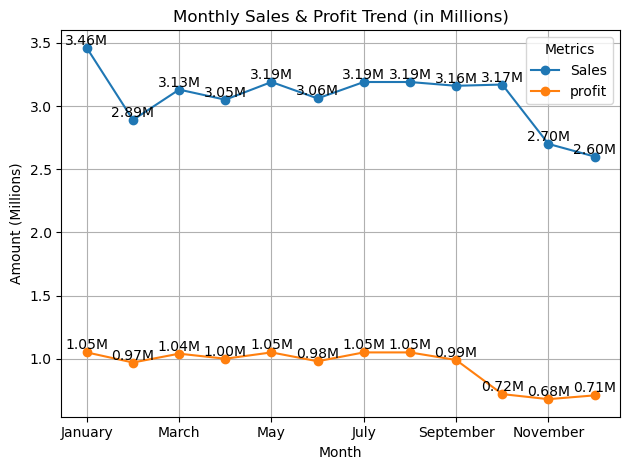

In [142]:

monthly_sales = (df.groupby("order_month_name")
                 .agg({"Sales": "sum", "profit": "sum"}) / 1_000_000).round(2)

# Correct month order
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

monthly_sales = monthly_sales.reindex(month_order)

# Plot
plt.figure(figsize=(15,10))
ax = monthly_sales.plot(marker='o')

# Add data labels
for col in monthly_sales.columns:
    for i, value in enumerate(monthly_sales[col]):
        if pd.notna(value):
            plt.text(i, value, f"{value:.2f}M", ha='center', va='bottom')

plt.title("Monthly Sales & Profit Trend (in Millions)")
plt.xlabel("Month")
plt.ylabel("Amount (Millions)")
plt.grid(True)
plt.legend(title="Metrics")

plt.tight_layout()
plt.show()

In [143]:
delivery_pivot = df.pivot_table(index='Delivery Status',
                               columns='order_month_name',
                               aggfunc='size',
                               fill_value=0)

print(delivery_pivot)

order_month_name   April  August  December  February  January  July  June  \
Delivery Status                                                             
Advance shipping    3607    3684      2917      3349     4162  3698  3510   
Late delivery       8378    8878      7063      7926     9827  8607  8300   
Shipping canceled    660     607       532       684      690   752   657   
Shipping on time    2790    2743      2252      2570     3300  2865  2672   

order_month_name   March   May  November  October  September  
Delivery Status                                               
Advance shipping    3719  3537      2875     2980       3554  
Late delivery       8796  8745      6819     7073       8565  
Shipping canceled    626   810       568      507        661  
Shipping on time    2778  2884      2238     2395       2709  


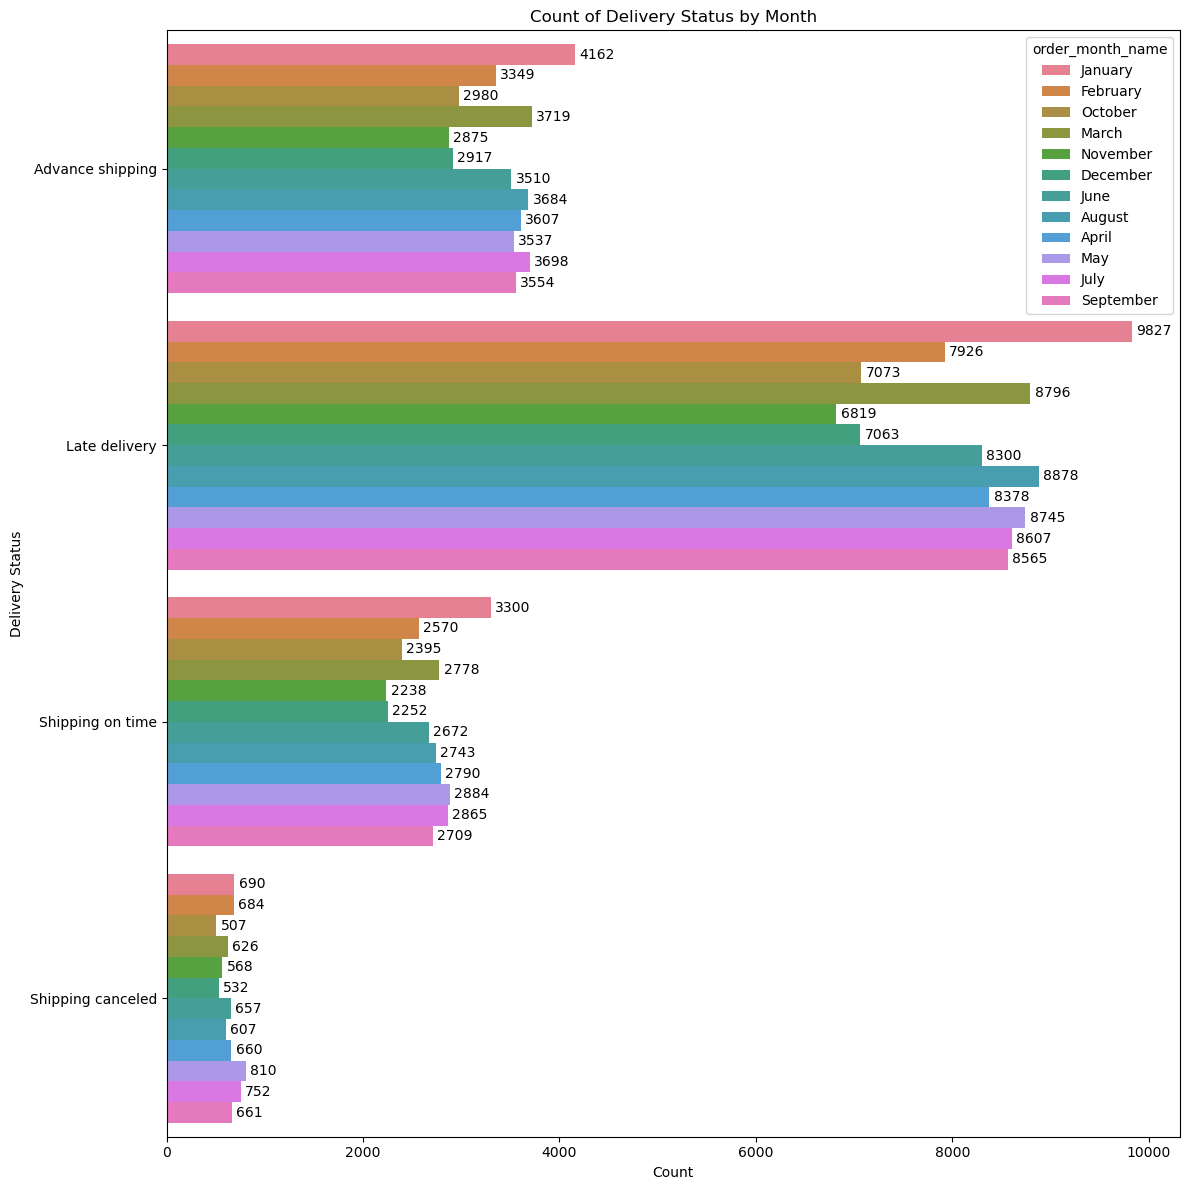

In [144]:
plt.figure(figsize=(12,12))

ax = sns.countplot(data=df, 
                   y='Delivery Status',
                   hue='order_month_name',
                   width=0.9) 

# Add data labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title("Count of Delivery Status by Month")
plt.xlabel("Count")
plt.ylabel("Delivery Status")
plt.tight_layout()
plt.show()

In [145]:
#  Weekly trend
weekly_sales = (df.groupby("order_day_name")
                .agg({"Sales": "sum", "profit": "sum"}) / 1_000_000).round(2)

weekly_sales_display = weekly_sales.astype(str) + "M"

print(weekly_sales_display)

                Sales profit
order_day_name              
Friday          5.31M  1.62M
Monday          5.28M   1.6M
Saturday        5.38M  1.64M
Sunday           5.3M  1.62M
Thursday        5.24M  1.61M
Tuesday          5.2M  1.59M
Wednesday       5.09M   1.6M


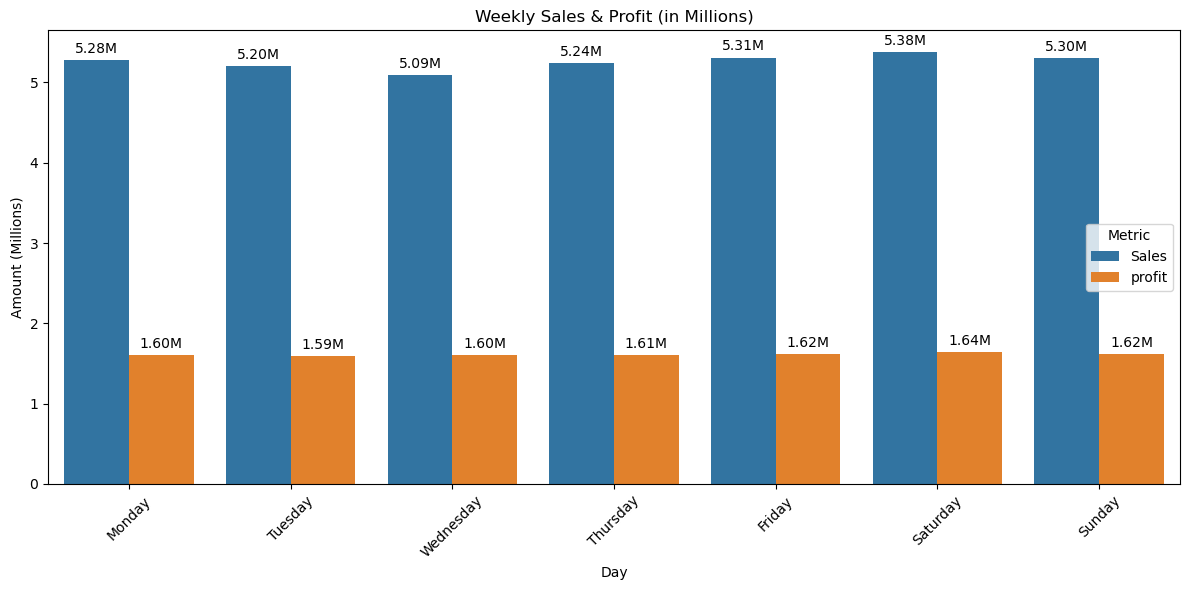

In [146]:
# Data (numeric)
weekly_sales = (df.groupby("order_day_name")
                .agg({"Sales": "sum", "profit": "sum"}) / 1_000_000).round(2)

# Correct weekday order
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", 
                 "Friday", "Saturday", "Sunday"]

weekly_sales = weekly_sales.reindex(weekday_order)

# Convert to long format for seaborn
weekly_sales_df = weekly_sales.reset_index().melt(id_vars='order_day_name',
                                                  var_name='Metric',
                                                  value_name='Value')

# Plot
plt.figure(figsize=(12,6))
ax = sns.barplot(data=weekly_sales_df,
                 x='order_day_name',
                 y='Value',
                 hue='Metric')

# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2fM', padding=3)

plt.title("Weekly Sales & Profit (in Millions)")
plt.xlabel("Day")
plt.ylabel("Amount (Millions)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

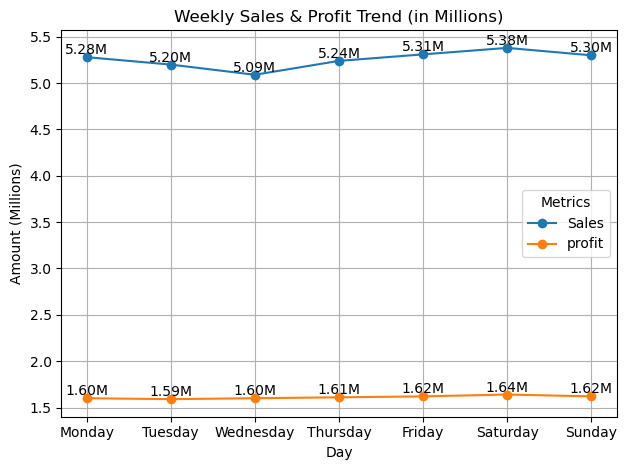

In [147]:
# Data (numeric)
weekly_sales = (df.groupby("order_day_name")
                .agg({"Sales": "sum", "profit": "sum"}) / 1_000_000).round(2)

# Correct weekday order
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", 
                 "Friday", "Saturday", "Sunday"]

weekly_sales = weekly_sales.reindex(weekday_order)

# Plot
plt.figure(figsize=(12,6))
ax = weekly_sales.plot(marker='o')

# Add data labels
for col in weekly_sales.columns:
    for i, value in enumerate(weekly_sales[col]):
        if pd.notna(value):
            plt.text(i, value, f"{value:.2f}M", ha='center', va='bottom')

plt.title("Weekly Sales & Profit Trend (in Millions)")
plt.xlabel("Day")
plt.ylabel("Amount (Millions)")
plt.grid(True)
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

In [148]:
delivery_pivot = df.pivot_table(index='Delivery Status',
                               columns='order_day_name',
                               aggfunc='size',
                               fill_value=0)

print(delivery_pivot)

order_day_name     Friday  Monday  Saturday  Sunday  Thursday  Tuesday  \
Delivery Status                                                          
Advance shipping     6027    5815      5975    5866      5918     6037   
Late delivery       14303   14196     14089   14300     14165    13913   
Shipping canceled    1050    1228      1147    1113      1039     1037   
Shipping on time     4545    4547      4690    4667      4630     4635   

order_day_name     Wednesday  
Delivery Status               
Advance shipping        5954  
Late delivery          14011  
Shipping canceled       1140  
Shipping on time        4482  


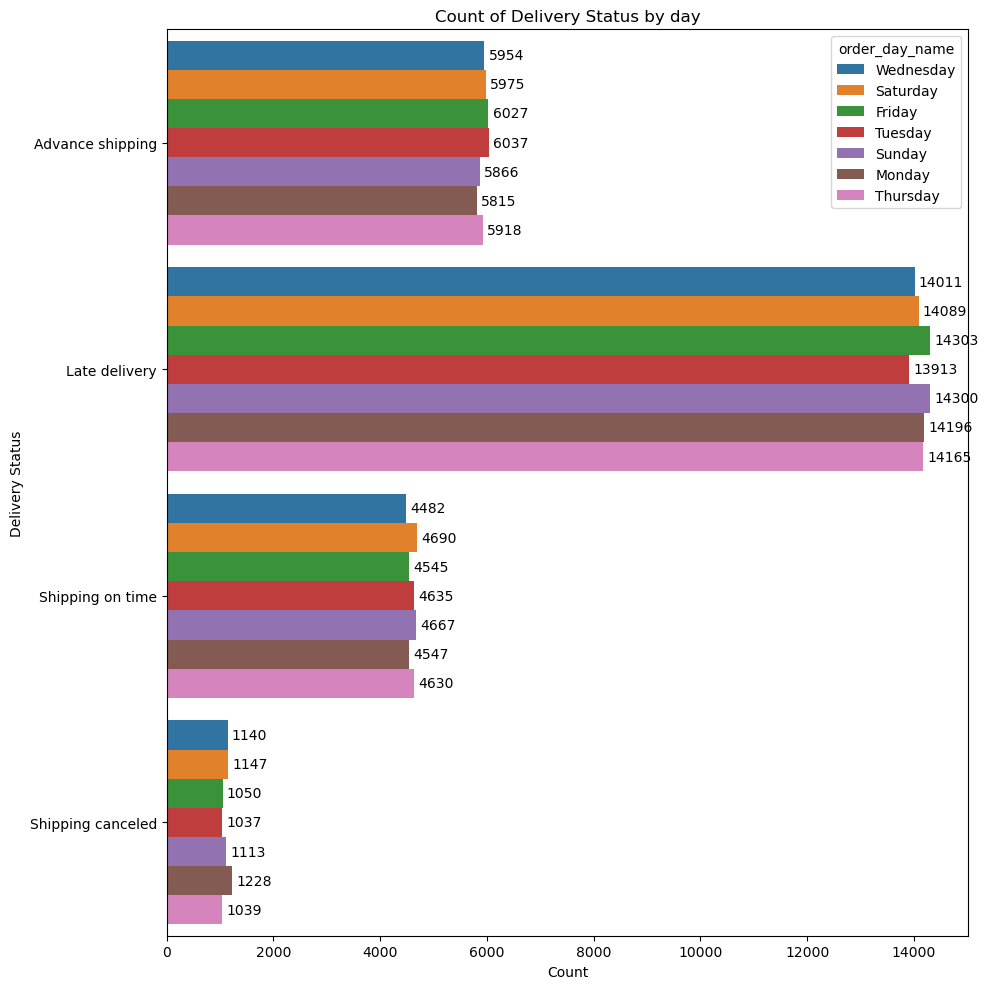

In [149]:
plt.figure(figsize=(10,10))

ax = sns.countplot(data=df, 
                   y='Delivery Status',
                   hue='order_day_name',
                   width=0.9)   
# Add data labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title("Count of Delivery Status by day")
plt.xlabel("Count")
plt.ylabel("Delivery Status")
plt.tight_layout()
plt.show()

In [150]:
cat_profit = round(df.groupby('Category Name')['Order Profit Per Order'].sum(),2).sort_values(ascending=False).head(10)
cat_profit 

Category Name
Fishing                 756220.77
Cleats                  494636.92
Camping & Hiking        427455.57
Cardio Equipment        383011.10
Women's Apparel         350421.03
Water Sports            325146.96
Indoor/Outdoor Games    318451.43
Men's Footwear          311902.82
Shop By Sport           129813.96
Computers                69656.81
Name: Order Profit Per Order, dtype: float64

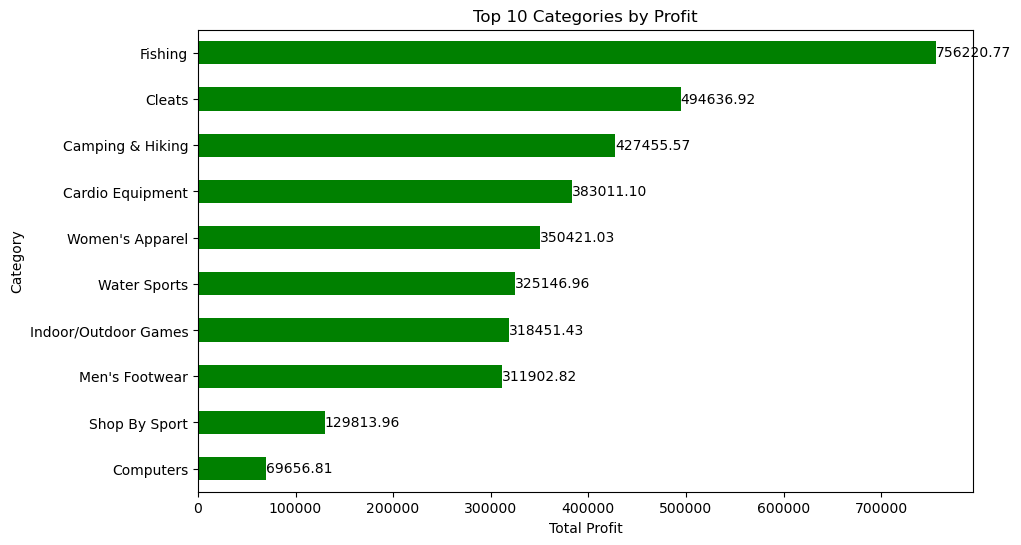

In [151]:

plt.figure(figsize=(10,6))
ax = cat_profit.plot(kind='barh',color="g")

plt.title('Top 10 Categories by Profit')
plt.xlabel('Total Profit')
plt.ylabel('Category')
plt.gca().invert_yaxis()

#  Add data labels
for i, v in enumerate(cat_profit):
    ax.text(v, i, f'{v:.2f}', va='center')

plt.show()

Customer Segment
Consumer        19.1M
Corporate      11.17M
Home Office     6.52M
Name: Sales, dtype: object


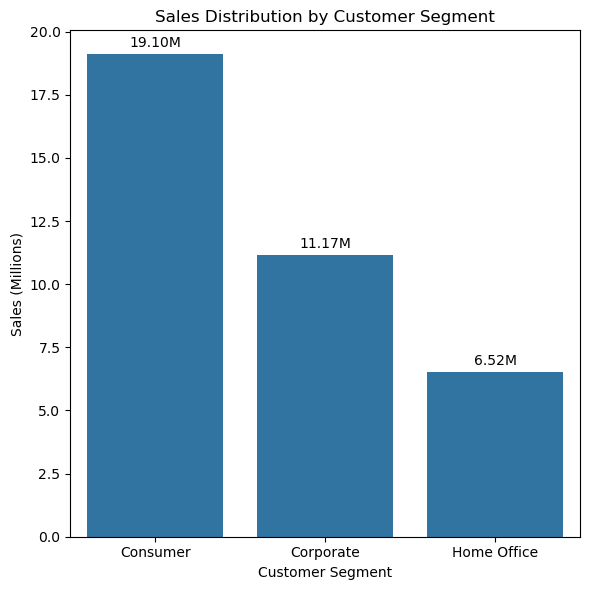

In [152]:
# Step 1: Calculate (keep as numeric)
cust_seg = round(df.groupby('Customer Segment')['Sales'].sum() / 1_000_000, 2)

# Step 2: Print with "M" (just for display)
print(cust_seg.astype(str) + "M")

# Step 3: Convert to DataFrame
cust_seg_df = cust_seg.reset_index()
cust_seg_df.columns = ['Customer Segment', 'Sales']

# Step 4: Plot
plt.figure(figsize=(6, 6))
ax = sns.barplot(data=cust_seg_df,
                 x='Customer Segment',
                 y='Sales')

for container in ax.containers:
    ax.bar_label(container,
                 labels=[f"{v.get_height():.2f}M" for v in container],
                 padding=3)

plt.title("Sales Distribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Sales (Millions)")
plt.tight_layout()
plt.show()

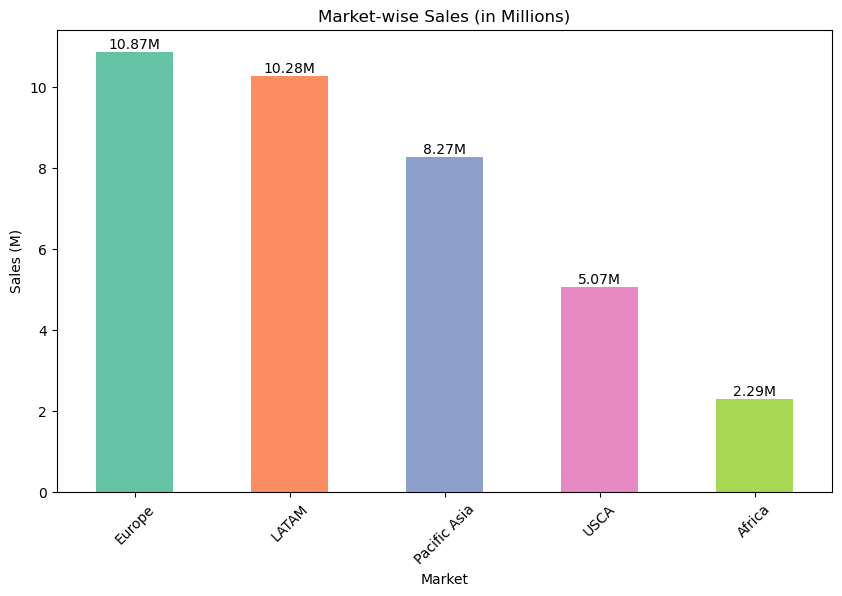

In [153]:
#  Market Share by Revenue 
market_rev = df.groupby('Market')['Sales'] \
               .sum().sort_values(ascending=False) / 1_000_000

plt.figure(figsize=(10,6))

colors = plt.cm.Set2.colors

ax = market_rev.plot(kind='bar', color=colors)

plt.title('Market-wise Sales (in Millions)')
plt.xlabel('Market')
plt.ylabel('Sales (M)')

for i, v in enumerate(market_rev):
    ax.text(i, v, f'{v:.2f}M', ha='center', va='bottom')

plt.xticks(rotation=45)
plt.show()

In [154]:
# Top 10 Categories by Revenue
cat_rev = df.groupby('Category Name')['Sales'] \
            .sum().round(2) \
            .sort_values(ascending=True).head(10)

print(cat_rev)

Category Name
CDs                   3059.59
Toys                  6104.66
Golf Bags & Carts    10369.39
Baby                 12229.56
Books                12587.40
As Seen on  TV!      20597.94
Soccer               26477.05
Basketball           27099.33
Video Games          33310.50
Golf Apparel         34969.75
Name: Sales, dtype: float64


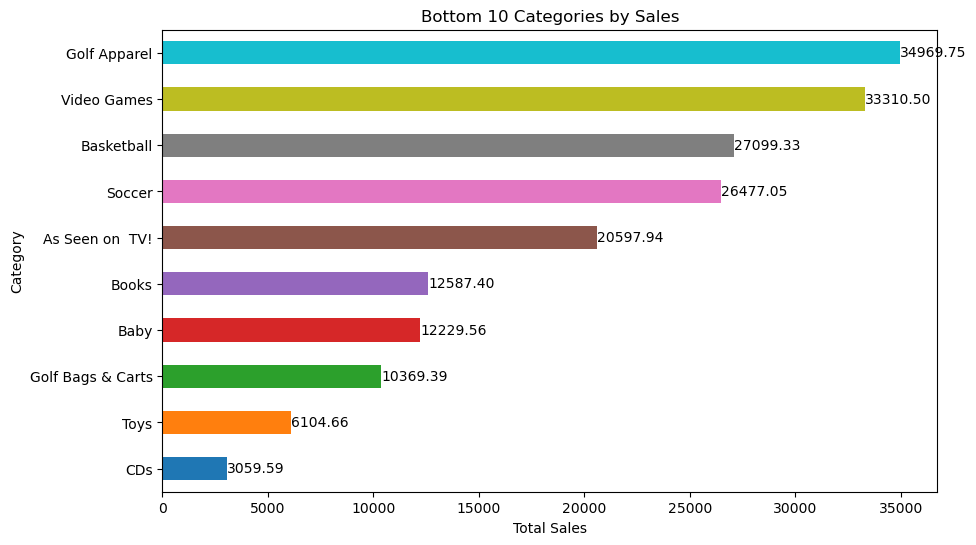

In [155]:
plt.figure(figsize=(10,6))

# Create bar chart with different colors
colors = plt.cm.tab10.colors  # built-in color palette
ax = cat_rev.plot(kind='barh', color=colors)

plt.title('Bottom 10 Categories by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Category')

for i, v in enumerate(cat_rev):
    ax.text(v, i, f'{v:.2f}', va='center')

plt.show()

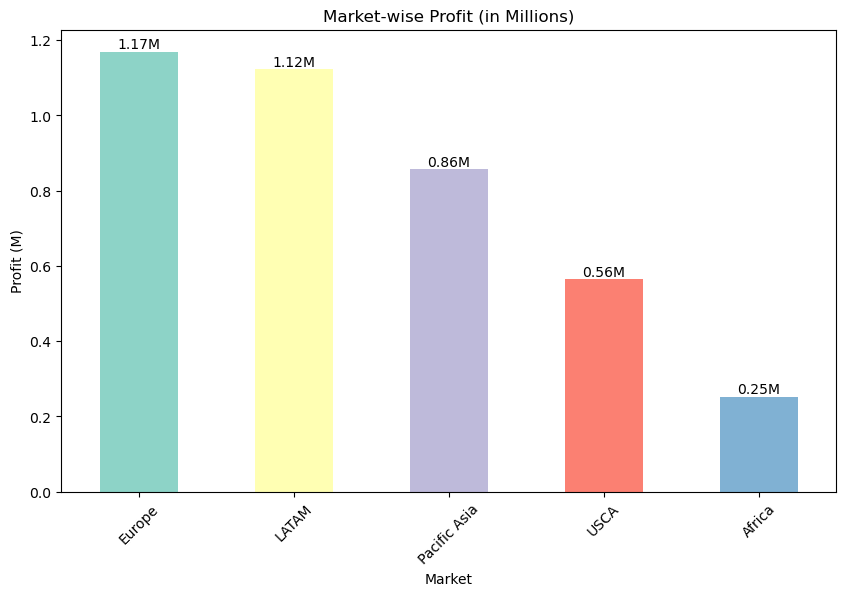

In [156]:
market_profit = df.groupby('Market')['Order Profit Per Order'] \
                  .sum().sort_values(ascending=False) / 1_000_000

plt.figure(figsize=(10,6))

colors = plt.cm.Set3.colors

ax = market_profit.plot(kind='bar', color=colors)

plt.title('Market-wise Profit (in Millions)')
plt.xlabel('Market')
plt.ylabel('Profit (M)')

for i, v in enumerate(market_profit):
    ax.text(i, v, f'{v:.2f}M', ha='center', va='bottom')

plt.xticks(rotation=45)
plt.show()

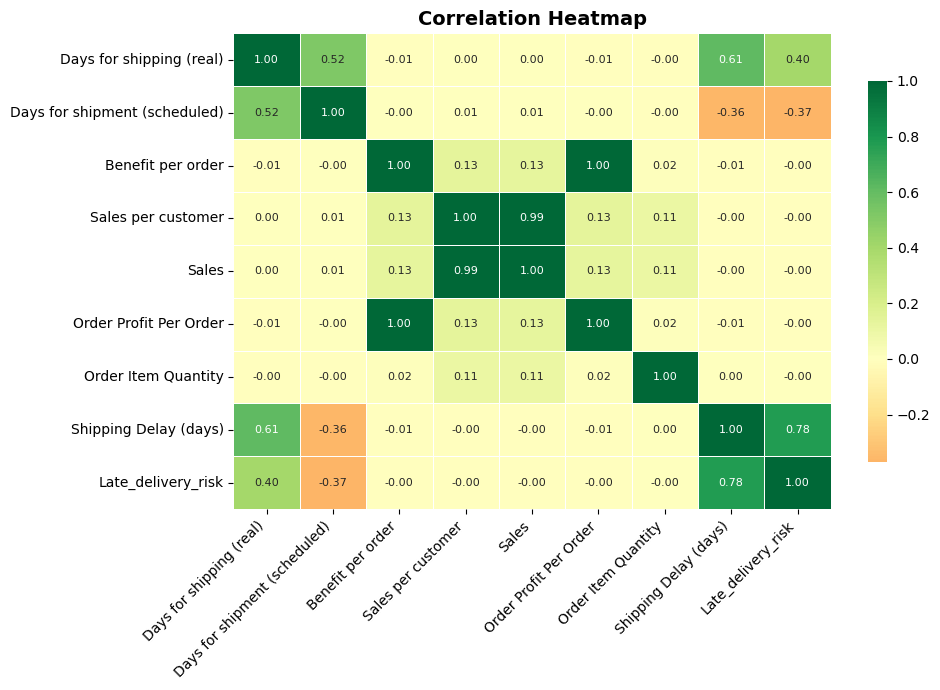

In [157]:
#Correlatinal H
num_cols = ['Days for shipping (real)', 'Days for shipment (scheduled)',
            'Benefit per order', 'Sales per customer', 'Sales',
            'Order Profit Per Order', 'Order Item Quantity',
            'Shipping Delay (days)', 'Late_delivery_risk']

num_cols = [c for c in num_cols if c in df.columns]

# Correlation matrix
corr = df[num_cols].corr()

# Create figure
plt.figure(figsize=(10,7))

ax = sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 8},
    cbar_kws={'shrink': 0.8}
)

# Titles & styling
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Save & show
plt.tight_layout()
plt.savefig('supply_chain_eda_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()

### STATISTICAL TESTS

In [158]:
# TEST 1: ONE-SAMPLE T-TEST
# Is average shipping delay significantly different from 0?
from scipy.stats import ttest_1samp

ALPHA = 0.05

def result_label(p):
    return "Reject Null Hypothesis" if p < ALPHA else "Fail to Reject Null Hypothesis"

if 'Shipping Delay (days)' in df.columns:
    delay = df['Shipping Delay (days)'].dropna()

    stat, p = ttest_1samp(delay, popmean=0)

    print(f"Sample Mean = {delay.mean():.4f} days")
    print(f"T-Statistic = {stat:.4f} | p-value = {p:.6f}")
    print(result_label(p))

    if p < ALPHA:
        print(f"→ Mean delay ({delay.mean():.2f} days) is significantly different from 0.")
    else:
        print("→ No significant difference from 0 delay.")

Sample Mean = 0.5658 days
T-Statistic = 161.2361 | p-value = 0.000000
Reject Null Hypothesis
→ Mean delay (0.57 days) is significantly different from 0.


In [159]:
 # INDEPENDENT T-TEST
# Do late deliveries have significantly higher shipping delay?
from scipy.stats import ttest_ind

# Helper function to interpret p-value
def result_label(p):
    if p < 0.05:
        return " Statistically Significant (reject H₀)"
    else:
        return " Not Statistically Significant (fail to reject H₀)"

# T-Test
if all(c in df.columns for c in ['Delivery Status', 'Shipping Delay (days)']):
    late    = df[df['Delivery Status'] == 'Late delivery']['Shipping Delay (days)'].dropna()
    on_time = df[df['Delivery Status'] != 'Late delivery']['Shipping Delay (days)'].dropna()

    stat, p = ttest_ind(late, on_time, equal_var=False)

    print(f"  Late Delivery   — Mean: {late.mean():.3f} | Std: {late.std():.3f} | n={len(late):,}")
    print(f"  On-Time/Advance — Mean: {on_time.mean():.3f} | Std: {on_time.std():.3f} | n={len(on_time):,}")
    print(f"  T-Statistic = {stat:.4f}  |  p-value = {p:.6f}")
    print(f"  {result_label(p)}")
else:
    print("Required columns not found in DataFrame.")

  Late Delivery   — Mean: 1.618 | Std: 0.883 | n=98,977
  On-Time/Advance — Mean: -0.712 | Std: 1.000 | n=81,542
  T-Statistic = 519.2561  |  p-value = 0.000000
   Statistically Significant (reject H₀)


In [161]:
 # ONE-WAY ANOVA
# Do shipping delays differ significantly across shipping modes?
from scipy.stats import f_oneway
if all(c in df.columns for c in ['Shipping Mode', 'Shipping Delay (days)']):
    groups = [g['Shipping Delay (days)'].dropna().values
              for _, g in df.groupby('Shipping Mode')]
    stat, p = f_oneway(*groups)
    print(f"  Groups tested: {df['Shipping Mode'].nunique()} shipping modes")
    print(f"  Group means:")
    for mode, g in df.groupby('Shipping Mode')['Shipping Delay (days)']:
        print(f"    {mode:<20} → Mean: {g.mean():.3f} days | n={len(g):,}")
    print(f"\n  F-Statistic = {stat:.4f}  |  p-value = {p:.6f}")
    print(f"  {result_label(p)}")

  Groups tested: 4 shipping modes
  Group means:
    First Class          → Mean: 1.000 days | n=27,814
    Same Day             → Mean: 0.478 days | n=9,737
    Second Class         → Mean: 1.991 days | n=35,216
    Standard Class       → Mean: -0.004 days | n=107,752

  F-Statistic = 23246.0527  |  p-value = 0.000000
   Statistically Significant (reject H₀)


In [163]:
# CHI-SQUARE TEST
# Is there a relationship between Shipping Mode & Delivery Status?

if all(c in df.columns for c in ['Shipping Mode', 'Delivery Status']):
    ct = pd.crosstab(df['Shipping Mode'], df['Delivery Status'])
    chi2, p, dof, expected = chi2_contingency(ct)
    print("  Contingency Table (counts):")
    print(ct.to_string())
    print(f"\n  Chi2 Statistic = {chi2:.4f}  |  df = {dof}  |  p-value = {p:.6f}")
    print(f"  {result_label(p)}")
    if p < ALPHA:
        print("  → Shipping Mode significantly affects Delivery Status.")

  Contingency Table (counts):
Delivery Status  Advance shipping  Late delivery  Shipping canceled  Shipping on time
Shipping Mode                                                                        
First Class                     0          26513               1301                 0
Same Day                        0           4454                444              4839
Second Class                    0          26987               1410              6819
Standard Class              41592          41023               4599             20538

  Chi2 Statistic = 55782.4835  |  df = 9  |  p-value = 0.000000
   Statistically Significant (reject H₀)
  → Shipping Mode significantly affects Delivery Status.


In [164]:
# CHI-SQUARE TEST
# Is there a relationship between Customer Segment & Late Delivery Risk?

if all(c in df.columns for c in ['Customer Segment', 'Late_delivery_risk']):
    ct2 = pd.crosstab(df['Customer Segment'], df['Late_delivery_risk'])
    chi2, p, dof, _ = chi2_contingency(ct2)
    print("  Contingency Table:")
    print(ct2.to_string())
    print(f"\n  Chi2 = {chi2:.4f}  |  df = {dof}  |  p-value = {p:.6f}")
    print(f"  {result_label(p)}")


  Contingency Table:
Late_delivery_risk      0      1
Customer Segment                
Consumer            42256  51248
Corporate           24807  29982
Home Office         14479  17747

  Chi2 = 1.0247  |  df = 2  |  p-value = 0.599074
   Not Statistically Significant (fail to reject H₀)


In [165]:
 # PEARSON CORRELATION
# Is there a linear relationship between Discount Rate & Profit Ratio?
from scipy.stats import 
if all(c in df.columns for c in ['Order Item Discount Rate', 'Order Item Profit Ratio']):
    x = df['Order Item Discount Rate'].dropna()
    y = df['Order Item Profit Ratio'].dropna()
    common = df[['Order Item Discount Rate','Order Item Profit Ratio']].dropna()
    r, p = pearsonr(common['Order Item Discount Rate'], common['Order Item Profit Ratio'])
    print(f"  Pearson r = {r:.4f}  |  p-value = {p:.6f}")
    print(f"  {result_label(p)}")
    direction = "positive" if r > 0 else "negative"
    strength  = "strong" if abs(r) > 0.7 else "moderate" if abs(r) > 0.4 else "weak"
    print(f"  → {strength.capitalize()} {direction} correlation between discount and profit ratio.")


NameError: name 'pearsonr' is not defined

In [ ]:
# SPEARMAN CORRELATION (Non-parametric)
# Relationship between Real Shipping Days and Shipping Delay

if all(c in df.columns for c in ['Days for shipping (real)', 'Shipping Delay (days)']):
    common = df[['Days for shipping (real)','Shipping Delay (days)']].dropna()
    rho, p = spearmanr(common['Days for shipping (real)'],
                       common['Shipping Delay (days)'])
    print(f"  Spearman ρ (rho) = {rho:.4f}  |  p-value = {p:.6f}")
    print(f"  {result_label(p)}")